### Utilities

In [3]:
from monai.networks.nets import UNet
import torch
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

def make_unet(channels=(16, 32, 64, 128, 256)):
    model = UNet(
        spatial_dims=2,
        in_channels=3,
        out_channels=1,
        channels=channels,
        strides=(2, 2, 2, 2),
        num_res_units=2,
    )
    return model.to(device)

### Training Graphs

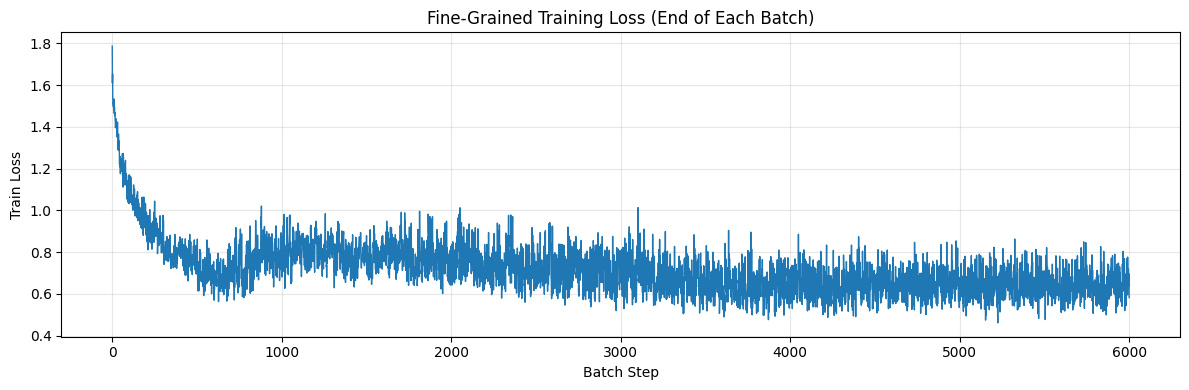

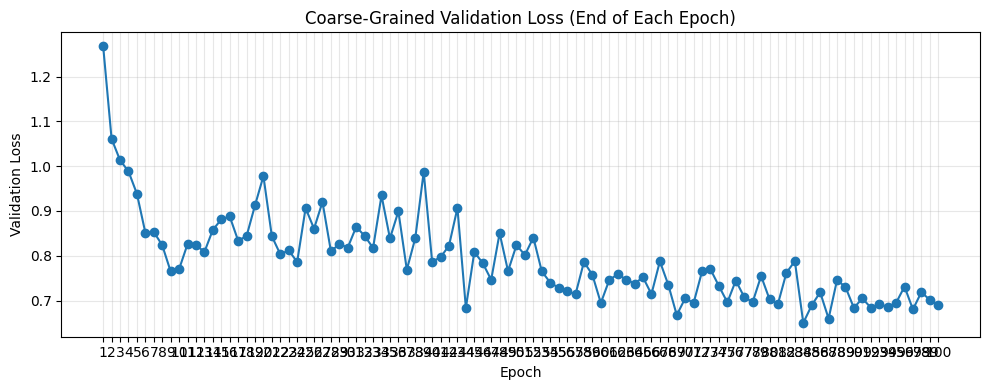

Loaded 100 epochs from /root/.cache/huggingface/hub/models--yu-alvin--Computer-Vision-2026/snapshots/60d035576e6ee4fcbac5c5ab8278bff8f3e36d03/models_betti/betti_history.csv
Plotted 6000 batch-level training-loss points


In [4]:
import ast
import pandas as pd
import matplotlib.pyplot as plt
from huggingface_hub import hf_hub_download

history_csv = hf_hub_download(
    repo_id="yu-alvin/Computer-Vision-2026",
    filename="models_betti/betti_history.csv",
    repo_type="model",
)

# history_csv = "/workspace/models_betti/betti_history.csv"
history_df = pd.read_csv(history_csv)

required_cols = {"epoch", "train_loss_steps", "val_loss"}
missing_cols = required_cols - set(history_df.columns)
if missing_cols:
    raise ValueError(f"Missing required columns in {history_csv}: {sorted(missing_cols)}")

# Parse stringified step-loss lists safely.
train_loss_steps_per_epoch = history_df["train_loss_steps"].apply(ast.literal_eval)

batch_steps = []
train_step_losses = []
step_idx = 1

for epoch_steps in train_loss_steps_per_epoch:
    batch_steps.extend(range(step_idx, step_idx + len(epoch_steps)))
    train_step_losses.extend(epoch_steps)
    step_idx += len(epoch_steps)

plt.figure(figsize=(12, 4))
plt.plot(batch_steps, train_step_losses, linewidth=1)
plt.title("Fine-Grained Training Loss (End of Each Batch)")
plt.xlabel("Batch Step")
plt.ylabel("Train Loss")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 4))
plt.plot(history_df["epoch"], history_df["val_loss"], marker="o", linewidth=1.5)
plt.title("Coarse-Grained Validation Loss (End of Each Epoch)")
plt.xlabel("Epoch")
plt.ylabel("Validation Loss")
plt.xticks(history_df["epoch"])
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Loaded {len(history_df)} epochs from {history_csv}")
print(f"Plotted {len(train_step_losses)} batch-level training-loss points")

### Hard Evaluation Functions

**Dice, IoU, Precision, Recall, F1**

In [5]:
import torch


def binary_segmentation_metrics(y_true: torch.Tensor, y_pred: torch.Tensor, threshold: float = 0.5, eps: float = 1e-7):
    """
    Compute Dice, IoU, precision, recall, and F1 for binary segmentation.
    """

    # We need to detach the tensors to avoid gradient computation
    y_true = y_true.detach()
    y_pred = y_pred.detach()

    # Threshold the predictions
    y_true = (y_true > 0.5).float()
    y_pred = (y_pred > threshold).float()

    # This gives 1D vectors
    y_true = y_true.view(-1)
    y_pred = y_pred.view(-1)

    tp = torch.sum((y_pred == 1) & (y_true == 1)).float()
    fp = torch.sum((y_pred == 1) & (y_true == 0)).float()
    fn = torch.sum((y_pred == 0) & (y_true == 1)).float()
    tn = torch.sum((y_pred == 0) & (y_true == 0)).float()

    dice = (2 * tp + eps) / (2 * tp + fp + fn + eps)
    iou = (tp + eps) / (tp + fp + fn + eps)
    precision = (tp + eps) / (tp + fp + eps)
    recall = (tp + eps) / (tp + fn + eps)
    f1 = (2 * precision * recall + eps) / (precision + recall + eps)  # This is literally the same as Dice, but we'll keep it for clarity

    return {
        "dice": dice.item(),
        "iou": iou.item(),
        "precision": precision.item(),
        "recall": recall.item(),
        "f1": f1.item(),
        "tp": tp.item(),
        "fp": fp.item(),
        "fn": fn.item(),
        "tn": tn.item(),
    }

**Betti Numbers**

In [7]:
import torch
import numpy as np
from scipy import ndimage


def beta0_beta1_2d(binary_mask: np.ndarray):
    """
    Computes Betti numbers for a 2D binary mask. 

    b_0 is the number of connected foreground components
    b_1 is the number of enclosed background holes inside foreground
    """
    binary_mask = binary_mask.astype(bool)

    # Foreground connectivity.
    # 4-connectivity is conservative for thin structures.
    fg_structure = ndimage.generate_binary_structure(2, 1)
    _, beta0 = ndimage.label(binary_mask, structure=fg_structure)

    # Background components.
    # Holes are background components that do NOT touch the image border.
    background = ~binary_mask

    # 8-connectivity for background is often paired with 4-connectivity foreground
    # to avoid ambiguous diagonal connections.
    bg_structure = ndimage.generate_binary_structure(2, 2)
    bg_labels, num_bg = ndimage.label(background, structure=bg_structure)

    if num_bg == 0:
        beta1 = 0
        return beta0, beta1

    border_labels = set()

    border_labels.update(np.unique(bg_labels[0, :]))
    border_labels.update(np.unique(bg_labels[-1, :]))
    border_labels.update(np.unique(bg_labels[:, 0]))
    border_labels.update(np.unique(bg_labels[:, -1]))

    # Label 0 is not a real component.
    border_labels.discard(0)

    all_bg_labels = set(range(1, num_bg + 1))
    hole_labels = all_bg_labels - border_labels

    beta1 = len(hole_labels)

    return beta0, beta1

def betti_error_one_image(logits, mask, threshold = 0.5, b0_weight = 1.0, b1_weight = 1.0):
    """
    Computes hard Betti error for one predicted mask and one ground truth mask.
    """
    probs = torch.sigmoid(logits)
    pred = (probs > threshold).float()

    pred_np = pred.detach().cpu().numpy()
    mask_np = mask.detach().cpu().numpy()

    # Remove channel dimension [1, H, W] -> [H, W]
    if pred_np.ndim == 3: pred_np = pred_np[0]
    if mask_np.ndim == 3: mask_np = mask_np[0]

    b0_pred, b1_pred = beta0_beta1_2d(pred_np)
    b0_gt, b1_gt = beta0_beta1_2d(mask_np)

    b0_error = abs(b0_pred - b0_gt)
    b1_error = abs(b1_pred - b1_gt)

    total_error = b0_weight * b0_error + b1_weight * b1_error
    loss = torch.tensor(total_error, device=logits.device, dtype=logits.dtype)

    stats = {
        "betti_loss": float(total_error),
        "b0_error": b0_error,
        "b1_error": b1_error,
        "betti_error": b0_error + b1_error,
        "b0_pred": b0_pred,
        "b1_pred": b1_pred,
        "b0_gt": b0_gt,
        "b1_gt": b1_gt,
    }

    return loss, stats

**Hard clDice**

In [8]:
from cldice import clDice

def hard_cldice_score(logits, masks, threshold=0.5, eps=1e-6):
    del eps  # kept for similar parameter names of hard dice
    probs = torch.sigmoid(logits)
    preds = (probs > threshold)
    masks = (masks > 0.5)

    # [B, 1, H, W] -> [B, H, W]
    preds = preds.squeeze(1)
    masks = masks.squeeze(1)

    cldice_scores = []
    for pred_i, mask_i in zip(preds, masks):
        pred_np = pred_i.detach().cpu().numpy().astype(np.bool_)
        mask_np = mask_i.detach().cpu().numpy().astype(np.bool_)

        if not pred_np.any() and not mask_np.any():
            score = 1.0
        else:
            score = float(clDice(pred_np, mask_np))
            if not np.isfinite(score):
                score = 0.0

        cldice_scores.append(score)

    if len(cldice_scores) == 0:
        return torch.tensor(0.0, device=logits.device)

    return torch.tensor(sum(cldice_scores) / len(cldice_scores), device=logits.device)

### Perform Evaluation

In [12]:
from statistics import mean
from fundus_dataset import FundusVesselDataset

import torch
from torch.utils.data import DataLoader
from safetensors.torch import load_file

test_ds = FundusVesselDataset(
    img_dir="../fundus/test/Original/",
    mask_dir="../fundus/test/Ground truth",
    transform=None,
)

test_loader = DataLoader(
    test_ds,
    batch_size=1,
    shuffle=False,
    num_workers=4,
    pin_memory=torch.cuda.is_available(),
)

eval_model = make_unet(channels=(32, 64, 128, 256, 512)).to(device)

model_path = hf_hub_download(
    repo_id="yu-alvin/Computer-Vision-2026",
    filename="models_betti/betti.safetensors",
    repo_type="model",
)

eval_model.load_state_dict(load_file(model_path))
eval_model.eval()


rows = []

with torch.no_grad():
    for idx, (images, masks) in enumerate(test_loader):
        name = test_ds.images[idx]

        images = images.to(device)
        masks = masks.to(device)

        logits = eval_model(images)
        probs = torch.sigmoid(logits)

        _, betti_stats = betti_error_one_image(logits[0], masks[0], threshold=0.5, b0_weight=1.0, b1_weight=1.0)

        hard_cldice = hard_cldice_score(logits, masks, threshold=0.5).item()

        row = {
            "image": name,
            **binary_segmentation_metrics(masks, probs, threshold=0.5),
            **betti_stats,
            "hard_cldice": hard_cldice,
        }
        rows.append(row)


binary_keys = ["dice", "iou", "precision", "recall", "f1"]
betti_keys = ["b0_error", "b1_error", "betti_error"]

print("Mean binary metrics:")
for key in binary_keys:
    print(f"  {key}: {mean(row[key] for row in rows):.6f}")

print("\nMean Betti / topological errors:")
for key in betti_keys:
    print(f"  {key}: {mean(row[key] for row in rows):.6f}")

cldice_keys = ["hard_cldice"]
print("\nMean clDice (hard):")
for key in cldice_keys:
    print(f"  {key}: {mean(row[key] for row in rows):.6f}")

Number of images: 200
Number of masks: 200
First 5 image files:  ['100_D.png', '101_G.png', '102_G.png', '103_G.png', '104_G.png']
First 5 mask files:  ['100_D.png', '101_G.png', '102_G.png', '103_G.png', '104_G.png']


models_betti/betti.safetensors:   0%|          | 0.00/26.0M [00:00<?, ?B/s]

Mean binary metrics:
  dice: 0.877534
  iou: 0.792000
  precision: 0.889533
  recall: 0.869405
  f1: 0.877534

Mean Betti / topological errors:
  b0_error: 72.745000
  b1_error: 10.400000
  betti_error: 83.145000

Mean clDice (hard):
  hard_cldice: 0.884304


### Top 5 Worst $B_0$

$B_0$ counts how many connected components the segmented foreground (vessels) has under 4-connectivity.

    image  b0_gt  b0_pred  b0_error  b1_error     dice
154_N.png     18      199       181         8 0.724450
177_N.png     15      194       179         0 0.883943
178_N.png     14      188       174         6 0.866272
188_N.png      9      174       165         7 0.886159
152_N.png      8      171       163        21 0.862722


/tmp/ipykernel_616117/4210431951.py:26: FutureWarning: `binary_dilation` is deprecated since version 0.26 and will be removed in version 0.28. Use `skimage.morphology.dilation` instead. Note the lack of mirroring for non-symmetric footprints (see docstring notes).
  return binary_dilation(


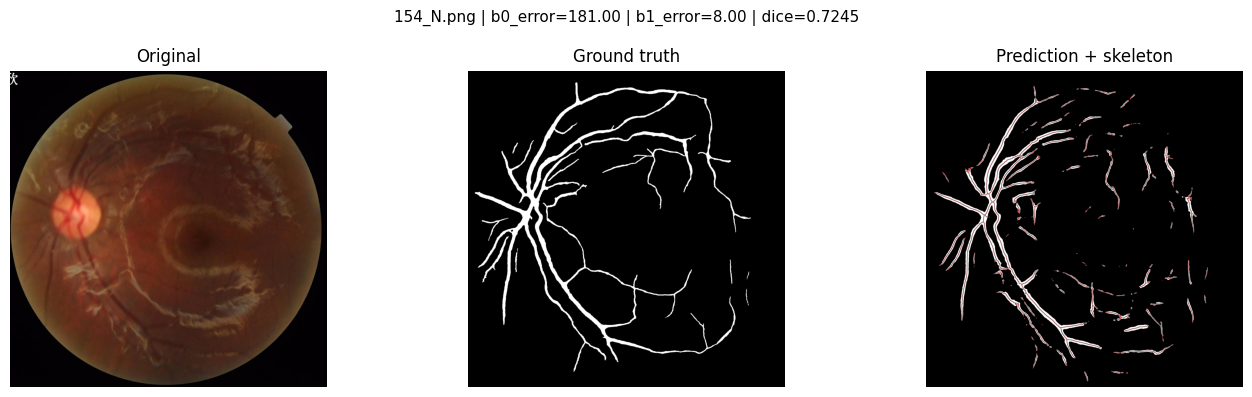

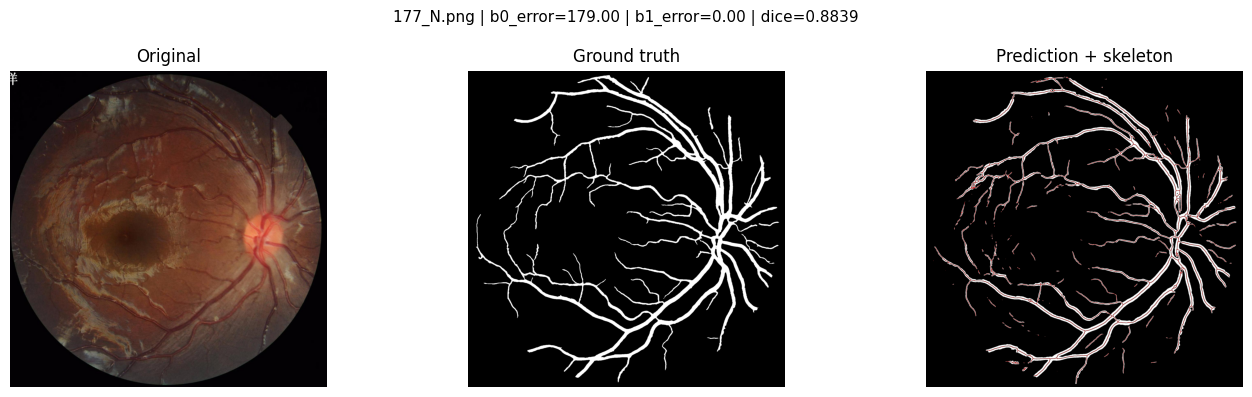

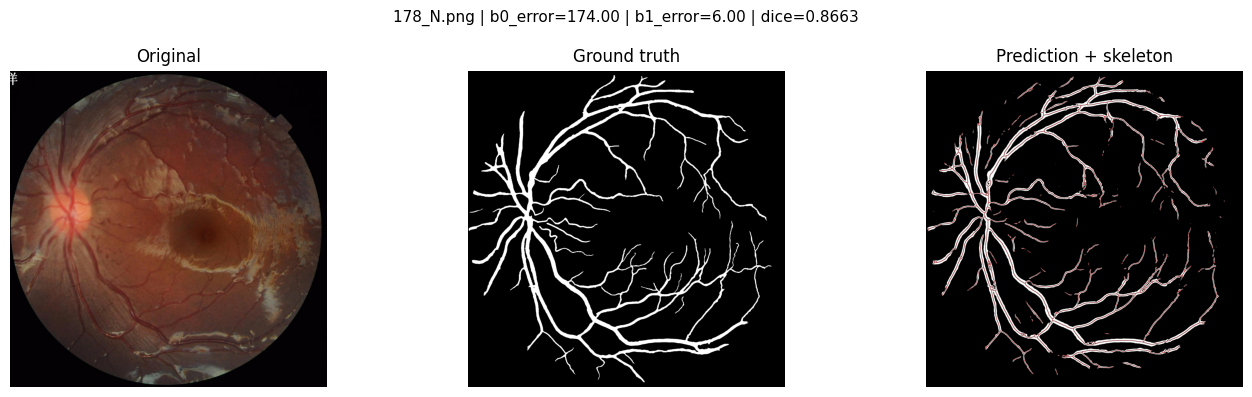

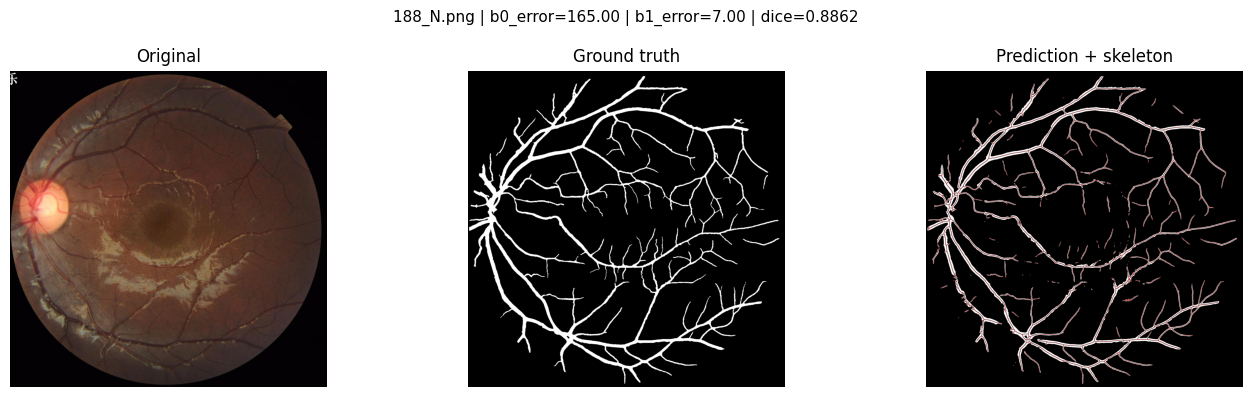

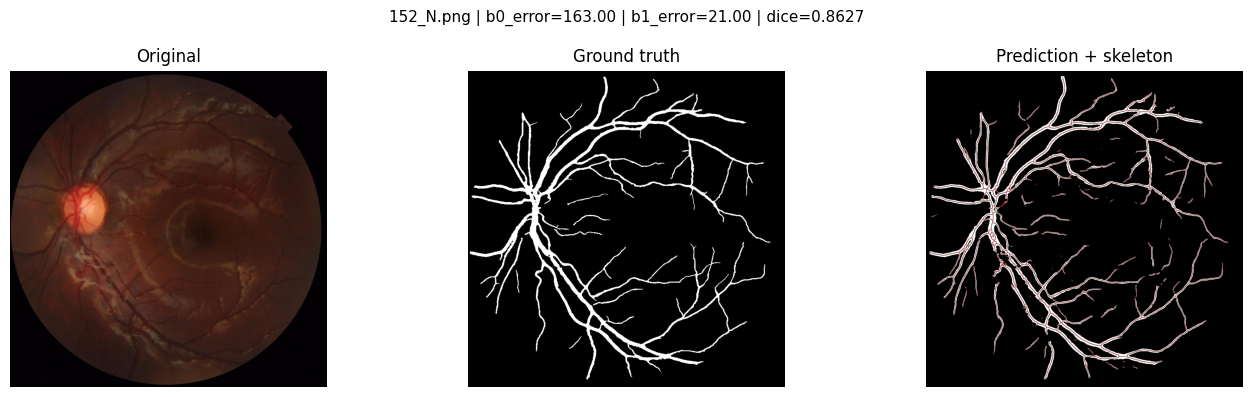

In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from skimage.morphology import skeletonize, binary_dilation

# Find the worst five and print summary
top5_b0 = sorted(rows, key=lambda r: r["b0_error"], reverse=True)[:5]
summary = pd.DataFrame(top5_b0)[["image", "b0_gt", "b0_pred", "b0_error", "b1_error", "dice"]]
print(summary.to_string(index=False))


# This predicts masks and thresholds
def predict(model, image, threshold=0.5):
    image = image.unsqueeze(0).to(device)

    with torch.no_grad():
        logits = model(image)
        probs = torch.sigmoid(logits)

    return (probs > threshold).cpu().numpy()[0, 0]

# This just returns the skeleton. Useful for visually inspecting topology
def skeleton(pred_mask):
    skeleton = skeletonize(pred_mask > 0)
    return binary_dilation(
        skeleton,
        footprint=np.ones((3, 3), dtype=bool),
    )

def display(row):
    image_name = row["image"]
    idx = test_ds.images.index(image_name)

    image, mask = test_ds[idx]

    pred_mask = predict(eval_model, image)
    skeleton_overlay = skeleton(pred_mask)

    original = image.numpy().transpose(1, 2, 0)
    gt_mask = mask.numpy()[0]

    fig, axes = plt.subplots(1, 3, figsize=(14, 4))

    axes[0].imshow(np.clip(original, 0.0, 1.0))
    axes[0].set_title("Original")

    axes[1].imshow(gt_mask, cmap="gray", vmin=0, vmax=1)
    axes[1].set_title("Ground truth")

    axes[2].imshow(pred_mask, cmap="gray", vmin=0, vmax=1)
    axes[2].imshow(
        np.ma.masked_where(~skeleton_overlay, skeleton_overlay),
        cmap="autumn",
        alpha=0.95,
    )
    axes[2].set_title("Prediction + skeleton")

    for ax in axes:
        ax.axis("off")

    fig.suptitle(
        f"{image_name} | "
        f"b0_error={row['b0_error']:.2f} | "
        f"b1_error={row['b1_error']:.2f} | "
        f"dice={row['dice']:.4f}",
        fontsize=11,
    )

    plt.tight_layout()
    plt.show()


# Show the plots
eval_model.eval()
for row in top5_b0: display(row)

### Top 5 Worst $B_1$

$B_1$ counts holes: background regions fully enclosed by foreground (8-connected background, ignoring components that touch the image border).

    image  b1_gt  b1_pred  b1_error  b0_error     dice
 62_D.png     79        9        70        59 0.747565
 91_D.png     79       21        58       108 0.863490
126_G.png     63        7        56        43 0.916065
137_G.png     33        0        33        51 0.747063
103_G.png     37       10        27        23 0.839413


/tmp/ipykernel_616117/4210431951.py:26: FutureWarning: `binary_dilation` is deprecated since version 0.26 and will be removed in version 0.28. Use `skimage.morphology.dilation` instead. Note the lack of mirroring for non-symmetric footprints (see docstring notes).
  return binary_dilation(


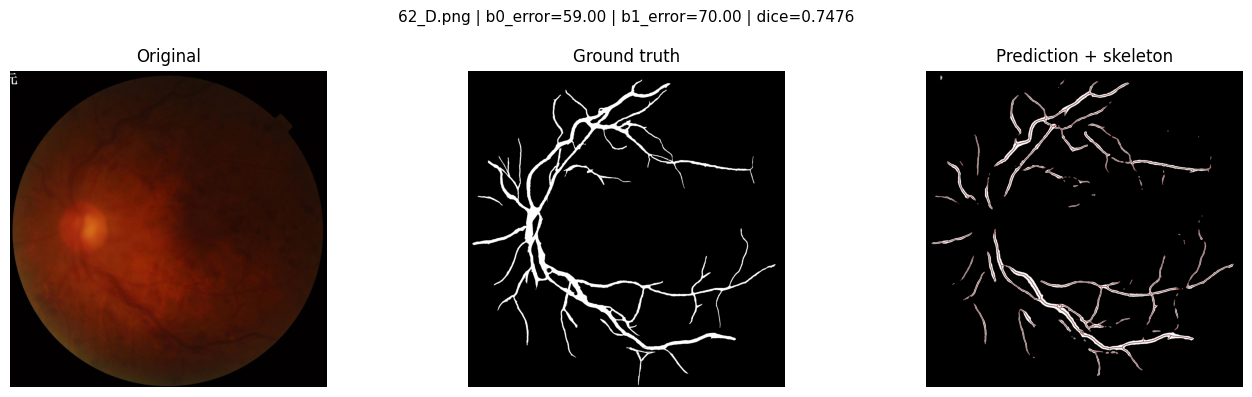

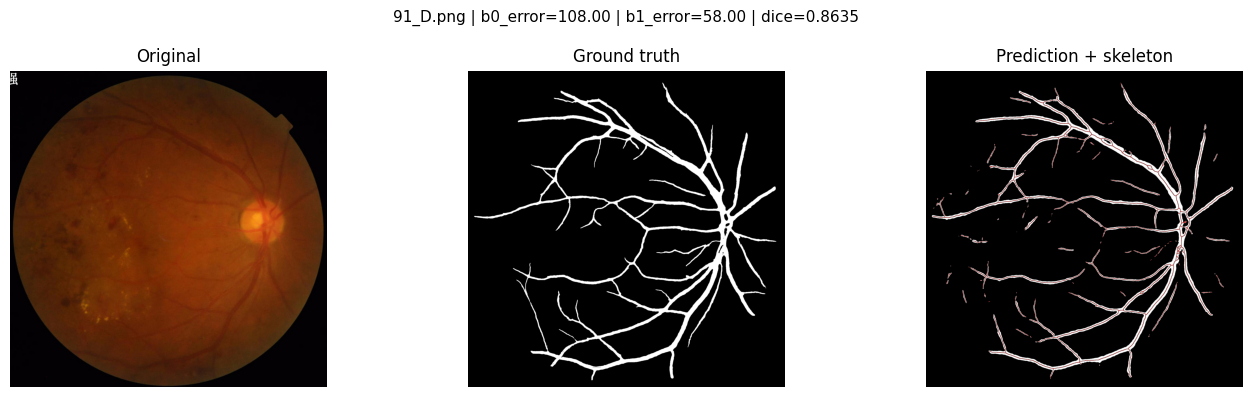

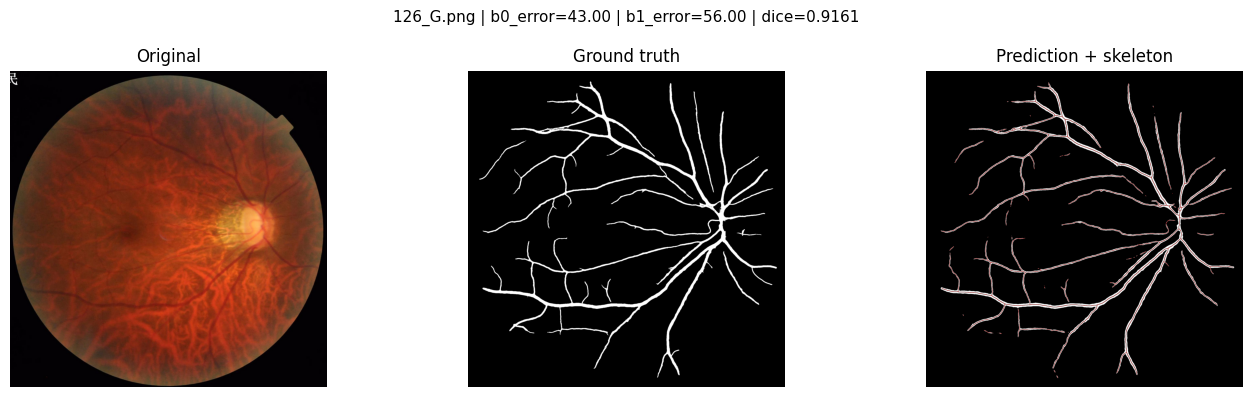

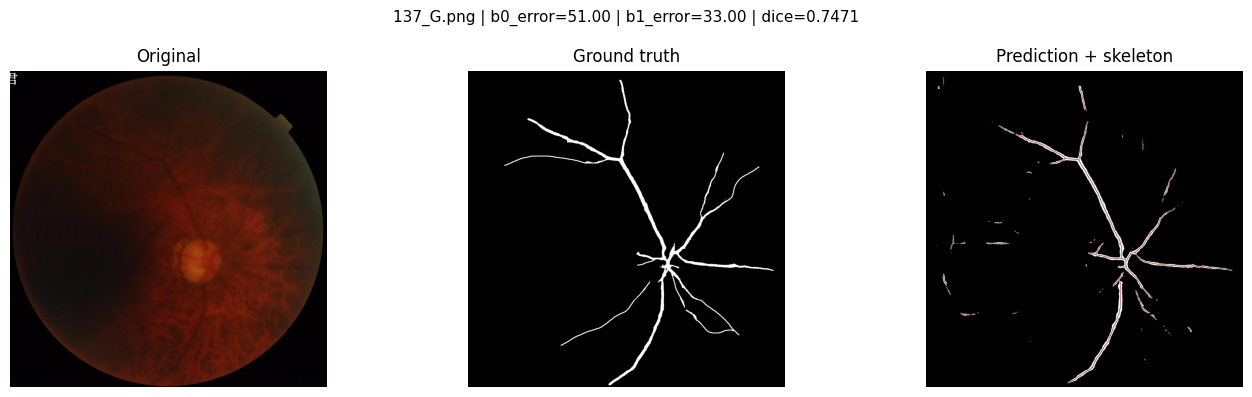

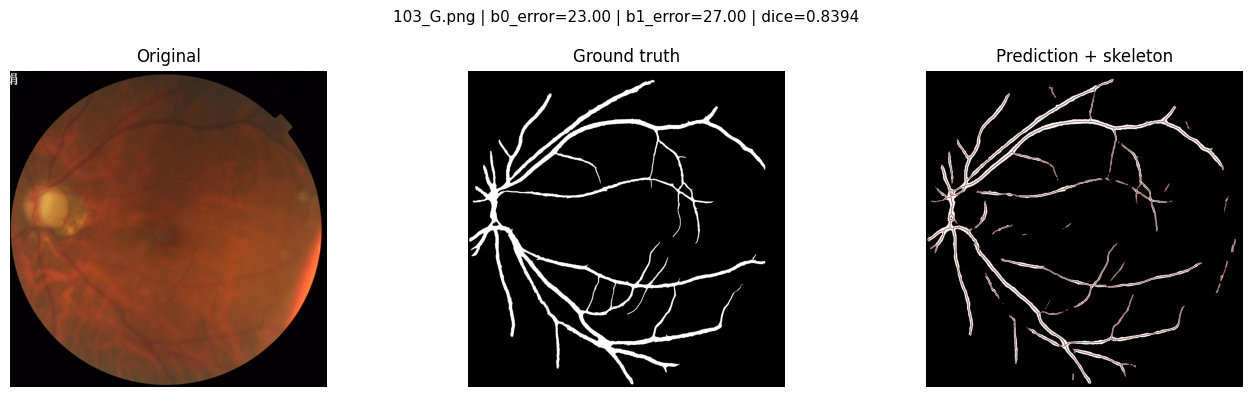

In [14]:
top5_b1 = sorted(rows, key=lambda r: r["b1_error"], reverse=True)[:5]
summary = pd.DataFrame(top5_b1)[["image", "b1_gt", "b1_pred", "b1_error", "b0_error", "dice"]]
print(summary.to_string(index=False))

# Show the plots
eval_model.eval()
for row in top5_b1: display(row)

### Best clDice

    image  hard_cldice     dice  b0_error  b1_error  betti_error
 13_A.png     0.966293 0.945821        28         4           32
 48_A.png     0.961927 0.946883        51         6           57
131_G.png     0.961724 0.946545        44         4           48
 14_A.png     0.961625 0.945118        50         7           57
 32_A.png     0.961206 0.945099        51         9           60


/tmp/ipykernel_616117/4210431951.py:26: FutureWarning: `binary_dilation` is deprecated since version 0.26 and will be removed in version 0.28. Use `skimage.morphology.dilation` instead. Note the lack of mirroring for non-symmetric footprints (see docstring notes).
  return binary_dilation(


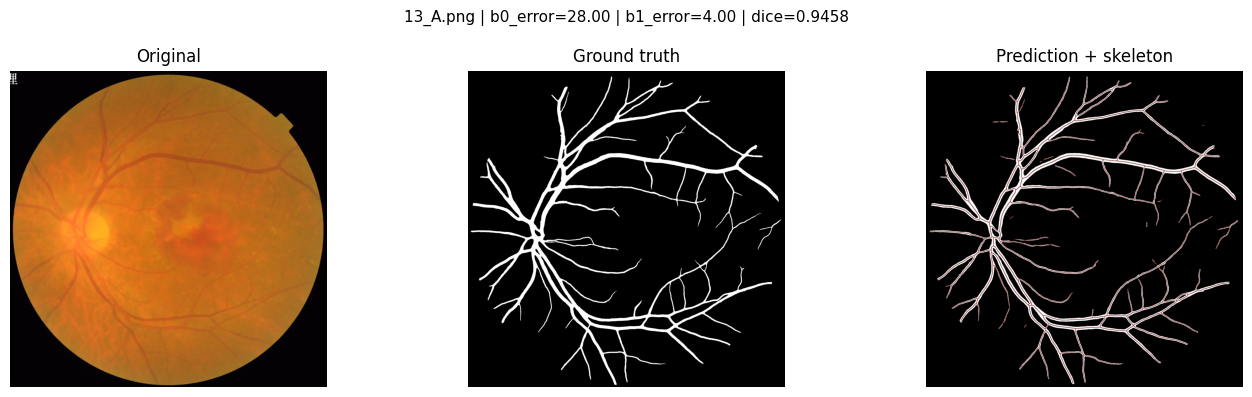

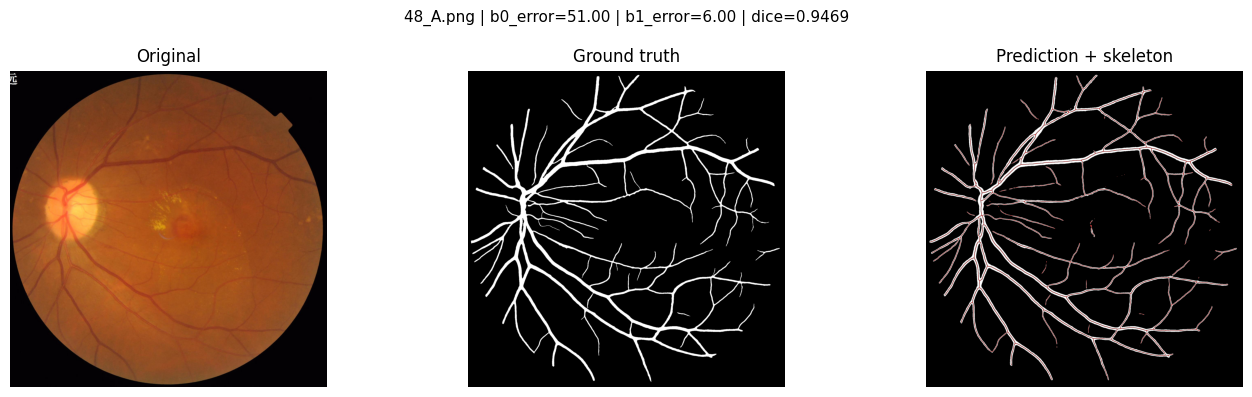

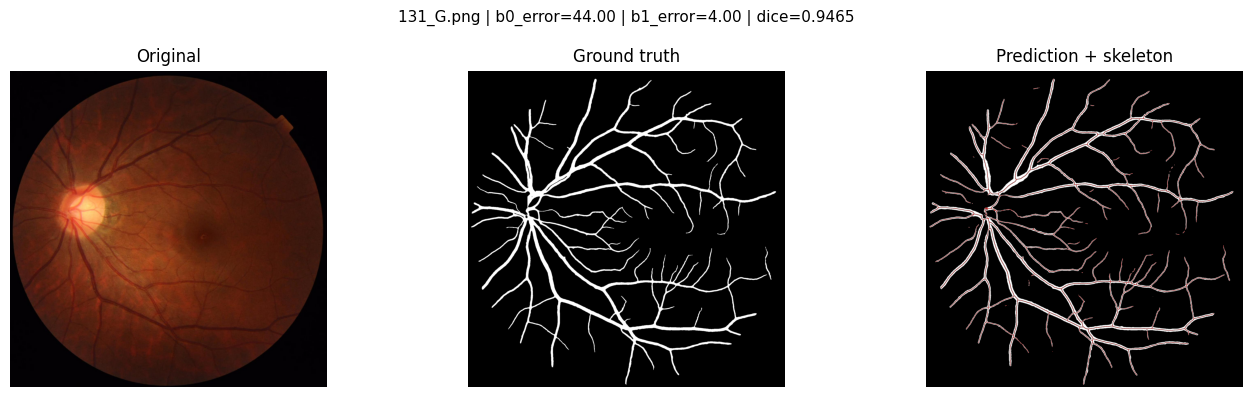

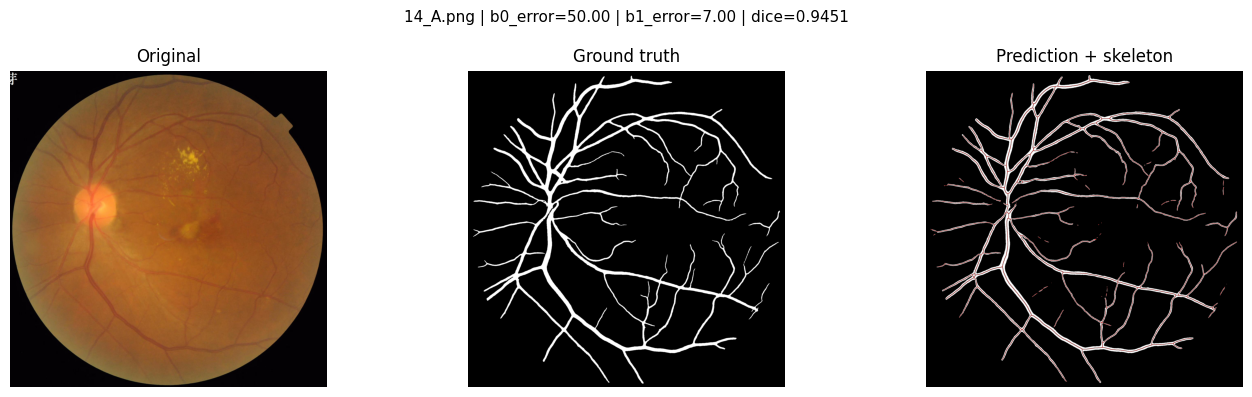

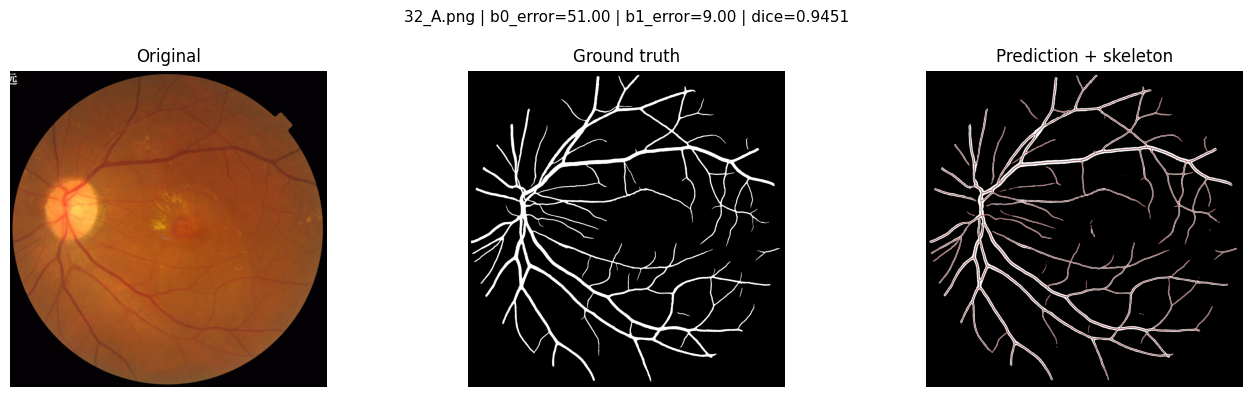

In [15]:
top5_cldice = sorted(rows, key=lambda r: r["hard_cldice"], reverse=True)[:5]

summary = pd.DataFrame(top5_cldice)[
    ["image", "hard_cldice", "dice", "b0_error", "b1_error", "betti_error"]
]

print(summary.to_string(index=False))

eval_model.eval()

for row in top5_cldice:
    display(row)